# Análisis de servicios mediante diagramas de Voronoi

**Lugar de estudio:** cabecera municipal de Santa Rosa del Sur, Bolívar, Colombia.

## Objetivo

Analizar la distribución espacial de droguerías, centros de salud e instituciones educativas mediante diagramas de Voronoi. Cada celda representa la zona cuyo establecimiento más cercano pertenece a un punto generador.

## Metodología

Las coordenadas del archivo están en EPSG:4326 (latitud y longitud). Se transforman a EPSG:9377, un sistema métrico, antes de calcular distancias euclidianas. Las celdas se construyen recortando una ventana rectangular mediante los semiplanos definidos por cada par de establecimientos.

La ventana es un dominio de análisis académico y no representa el perímetro urbano legal.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyproj import Transformer
from shapely.geometry import Polygon

DATA = Path("data/services.csv")
OUT = Path("figures")
OUT.mkdir(exist_ok=True)

df = pd.read_csv(DATA)
df

,tipo,nombre,lat,lon,zona,precision,fuente
0,farmacia,Drogas La Aspirina,7.96420,-74.05190,urbana,aproximada,Farmacolombia + dirección
1,farmacia,Beymax,7.96500,-74.05440,urbana,aproximada,Farmacolombia + dirección
2,farmacia,Droguería La Serranía,7.96600,-74.04880,urbana,aproximada,Farmacolombia + dirección
3,farmacia,D Central,7.96520,-74.05100,urbana,aproximada,Google Business + dirección
4,farmacia,Droguería San Martín de la 12,7.96680,-74.04750,urbana,aproximada,Google Business + dirección
5,farmacia,Droguería-Minimarket Al Frente,7.96800,-74.04740,urbana,aproximada,Google Business + dirección
6,salud,Hospital Manuel Elkin Patarroyo,7.96824,-74.04702,urbana,exacta,Mapcarta/OpenStreetMap
7,salud,Centro Médico Cruz Blanca,7.96600,-74.04880,urbana,aproximada,Google Business + dirección
8,salud,Centro Médico Soluciones SAS,7.96500,-74.05400,urbana,aproximada,Google Business + dirección
9,salud,Consultorio Odontológico David José García,7.96540,-74.05000,urbana,aproximada,Google Business + dirección


## Datos

El conjunto contiene 14 establecimientos: seis farmacias, cinco servicios de salud y tres colegios. Las coordenadas aproximadas introducen incertidumbre en la ubicación de algunos puntos.

In [2]:
df.groupby("tipo").size().rename("cantidad").to_frame()

,cantidad
tipo,
colegio,3
farmacia,6
salud,5


## Proyección a coordenadas métricas

Se usa `pyproj` para pasar de longitud/latitud a Este/Norte en metros. Así, las comparaciones de distancia tienen una interpretación geométrica coherente.

In [3]:
TO_9377 = Transformer.from_crs("EPSG:4326", "EPSG:9377", always_xy=True)


def project(lon, lat):
    x, y = TO_9377.transform(lon, lat)
    return np.asarray(x), np.asarray(y)


def xy(sub):
    x, y = project(sub["lon"].to_numpy(), sub["lat"].to_numpy())
    return np.column_stack((x, y))


ALL_POINTS = xy(df)
MIN_X, MAX_X = ALL_POINTS[:, 0].min(), ALL_POINTS[:, 0].max()
MIN_Y, MAX_Y = ALL_POINTS[:, 1].min(), ALL_POINTS[:, 1].max()
MARGIN = 1300.0
PLOT_BOUNDS = (MIN_X - MARGIN, MIN_Y - MARGIN, MAX_X + MARGIN, MAX_Y + MARGIN)

STUDY_WINDOW = Polygon([
    (PLOT_BOUNDS[0], PLOT_BOUNDS[1]),
    (PLOT_BOUNDS[2], PLOT_BOUNDS[1]),
    (PLOT_BOUNDS[2], PLOT_BOUNDS[3]),
    (PLOT_BOUNDS[0], PLOT_BOUNDS[3]),
])

PLOT_BOUNDS

(np.float64(4882469.990476361),
 np.float64(2436884.7710424736),
 np.float64(4885950.294185583),
 np.float64(2439929.927289469))

## Construcción de las celdas

Para un punto $p_i$ y otro punto $p_j$, se conserva el semiplano que cumple:

$$2(p_j-p_i)\cdot x \leq \|p_j\|^2 - \|p_i\|^2$$

Al aplicar la condición frente a todos los demás puntos, queda la región donde el establecimiento $i$ es el más cercano.

In [4]:
def clip_polygon_with_halfplane(polygon, a, b, c, eps=1e-9):
    """Conserva del polígono los puntos que cumplen a*x + b*y <= c."""
    if polygon.is_empty:
        return polygon

    coords = list(polygon.exterior.coords)
    result = []

    def value(point):
        x, y = point
        return a * x + b * y - c

    for i in range(len(coords) - 1):
        current = np.asarray(coords[i], dtype=float)
        next_point = np.asarray(coords[i + 1], dtype=float)
        current_value = value(current)
        next_value = value(next_point)
        current_inside = current_value <= eps
        next_inside = next_value <= eps

        if current_inside and next_inside:
            result.append(next_point)
        elif current_inside and not next_inside:
            direction = next_point - current
            denominator = a * direction[0] + b * direction[1]
            if abs(denominator) > eps:
                result.append(current - current_value * direction / denominator)
        elif not current_inside and next_inside:
            direction = next_point - current
            denominator = a * direction[0] + b * direction[1]
            if abs(denominator) > eps:
                result.append(current - current_value * direction / denominator)
            result.append(next_point)

    if len(result) < 3:
        return Polygon()
    return Polygon(result).buffer(0)

## Función de Voronoi

Cada celda comienza como la ventana completa. Después se recorta frente a cada uno de los demás establecimientos de la misma categoría. Al final, las celdas forman una partición del dominio de análisis.

In [5]:
def voronoi_cells(points, bounding_polygon):
    cells = []
    for i, point_i in enumerate(points):
        cell = bounding_polygon
        for j, point_j in enumerate(points):
            if i == j:
                continue

            direction = point_j - point_i
            a = 2.0 * direction[0]
            b = 2.0 * direction[1]
            c = np.dot(point_j, point_j) - np.dot(point_i, point_i)
            cell = clip_polygon_with_halfplane(cell, a, b, c)

            if cell.is_empty:
                break
        cells.append(cell)
    return cells


farmacia_points = xy(df[df["tipo"] == "farmacia"])
farmacia_cells = voronoi_cells(farmacia_points, STUDY_WINDOW)
len(farmacia_cells)

6

In [6]:
sum(not cell.is_empty for cell in farmacia_cells), STUDY_WINDOW.area

(6, 10598068.58157918)

## Visualización

Las etiquetas identifican cada establecimiento. Las figuras se guardarán en `figures/` para poder reutilizarlas en el informe.

In [7]:
def draw_polygon(ax, geom, alpha=0.20):
    if geom.is_empty:
        return
    geometries = [geom] if geom.geom_type == "Polygon" else geom.geoms
    for part in geometries:
        x, y = part.exterior.xy
        ax.fill(x, y, alpha=alpha)
        ax.plot(x, y, linewidth=0.8)


def annotate_points(ax, points, sub, prefix):
    offsets = [(8, 8), (8, -14), (-8, 8), (-8, -14), (12, 20), (-12, 20)]
    for i, _ in sub.iterrows():
        x, y = points[i]
        dx, dy = offsets[i % len(offsets)]
        ax.annotate(
            f"{prefix}{i + 1}", xy=(x, y), xytext=(dx, dy),
            textcoords="offset points", fontsize=9, fontweight="bold",
            ha="left" if dx > 0 else "right",
            va="bottom" if dy > 0 else "top",
            bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.85},
            arrowprops={"arrowstyle": "-", "linewidth": 0.6}, zorder=5,
        )

## Diagramas por categoría

Se genera un diagrama independiente para cada tipo de servicio. No se mezclan los puntos porque cada categoría responde a una pregunta de cobertura diferente.

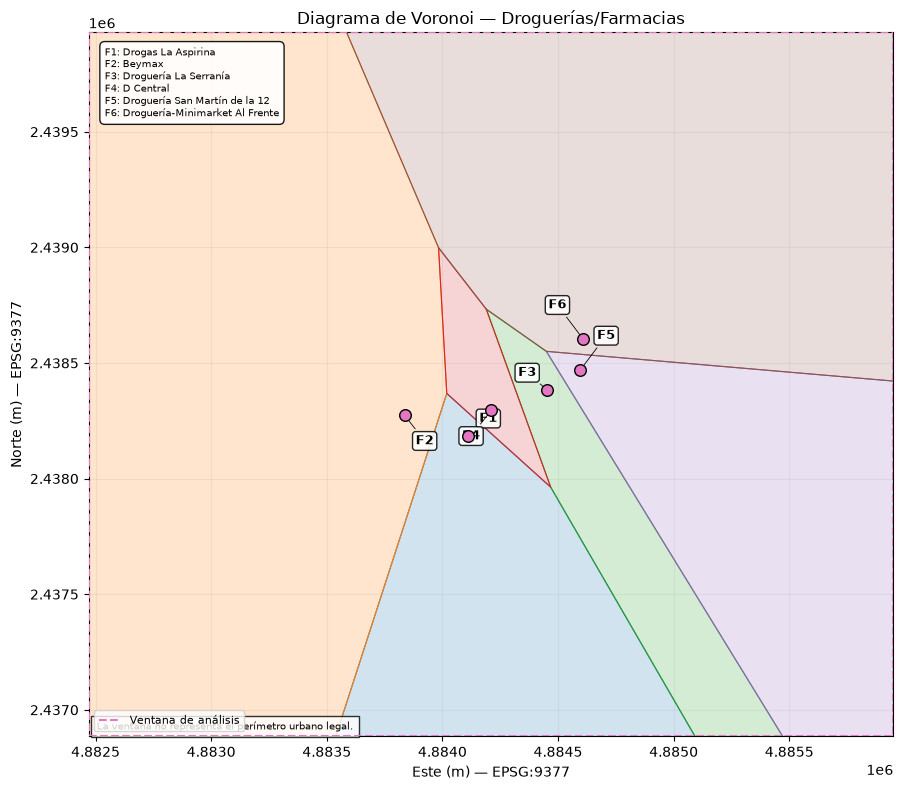

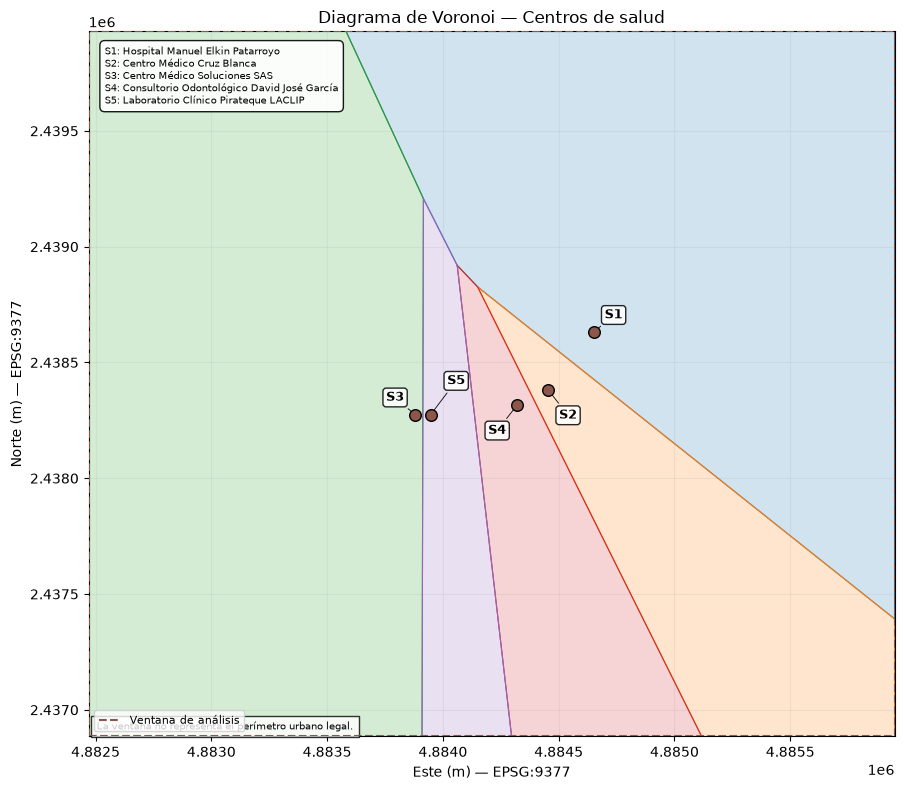

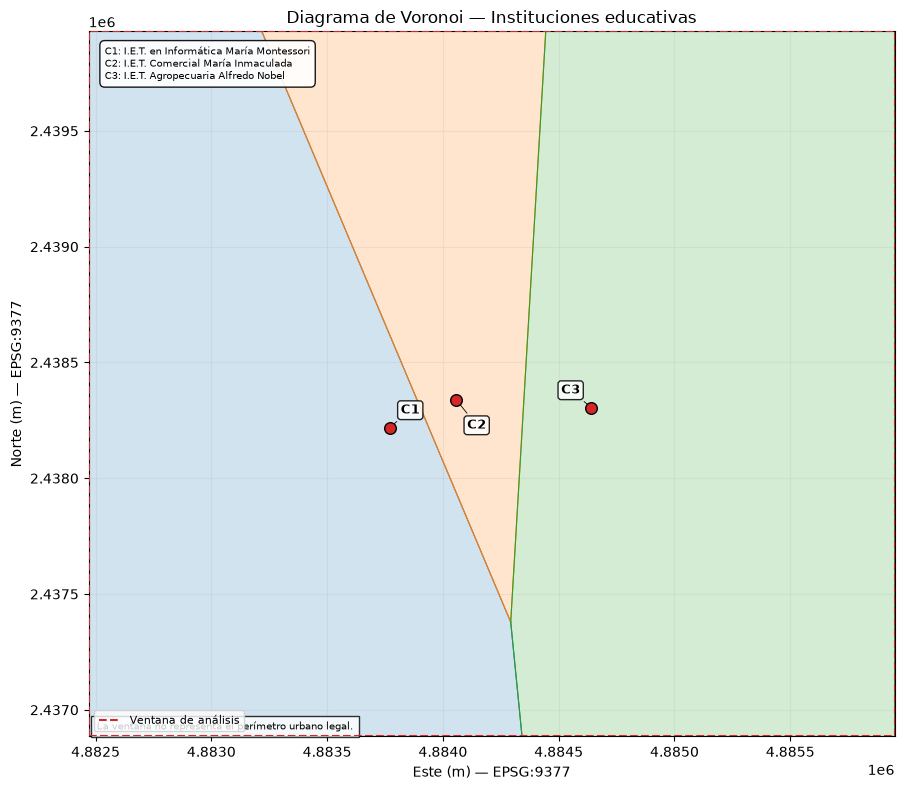

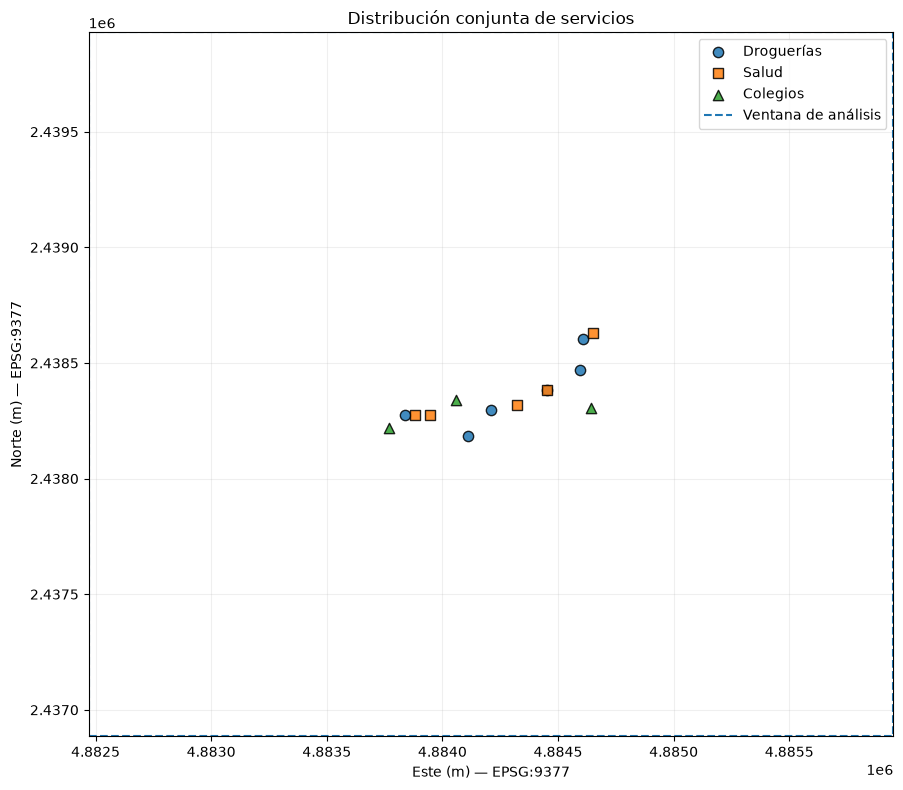

In [8]:
def plot_type(kind, title, filename, prefix):
    sub = df[df["tipo"] == kind].copy().reset_index(drop=True)
    points = xy(sub)
    cells = voronoi_cells(points, STUDY_WINDOW)

    fig, ax = plt.subplots(figsize=(10, 8))
    for cell in cells:
        draw_polygon(ax, cell)

    bx, by = STUDY_WINDOW.exterior.xy
    ax.plot(bx, by, "--", linewidth=1.5, label="Ventana de análisis", zorder=4)
    ax.scatter(points[:, 0], points[:, 1], s=70, edgecolor="black", zorder=6)
    annotate_points(ax, points, sub, prefix)

    legend_text = "\n".join(f"{prefix}{i + 1}: {row['nombre']}" for i, row in sub.iterrows())
    ax.text(0.02, 0.98, legend_text, transform=ax.transAxes, va="top", fontsize=7,
            bbox={"boxstyle": "round,pad=0.5", "facecolor": "white", "alpha": 0.9})
    ax.set_xlim(PLOT_BOUNDS[0], PLOT_BOUNDS[2])
    ax.set_ylim(PLOT_BOUNDS[1], PLOT_BOUNDS[3])
    ax.set_xlabel("Este (m) — EPSG:9377")
    ax.set_ylabel("Norte (m) — EPSG:9377")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.2)
    ax.legend(loc="lower left", fontsize=8)
    ax.text(0.01, 0.01, "La ventana no representa el perímetro urbano legal.",
            transform=ax.transAxes, fontsize=7, bbox={"facecolor": "white", "alpha": 0.8})
    fig.tight_layout()
    fig.savefig(OUT / filename, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)


plot_type("farmacia", "Diagrama de Voronoi — Droguerías/Farmacias", "voronoi_farmacias.png", "F")
plot_type("salud", "Diagrama de Voronoi — Centros de salud", "voronoi_salud.png", "S")
plot_type("colegio", "Diagrama de Voronoi — Instituciones educativas", "voronoi_colegios.png", "C")


markers = {"farmacia": "o", "salud": "s", "colegio": "^"}
labels = {"farmacia": "Droguerías", "salud": "Salud", "colegio": "Colegios"}
fig, ax = plt.subplots(figsize=(10, 8))
for kind in markers:
    sub = df[df["tipo"] == kind]
    points = xy(sub)
    ax.scatter(points[:, 0], points[:, 1], s=55, marker=markers[kind],
               label=labels[kind], alpha=0.85, edgecolor="black")

bx, by = STUDY_WINDOW.exterior.xy
ax.plot(bx, by, "--", linewidth=1.5, label="Ventana de análisis")
ax.set_xlim(PLOT_BOUNDS[0], PLOT_BOUNDS[2])
ax.set_ylim(PLOT_BOUNDS[1], PLOT_BOUNDS[3])
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Este (m) — EPSG:9377")
ax.set_ylabel("Norte (m) — EPSG:9377")
ax.set_title("Distribución conjunta de servicios")
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "distribucion_conjunta.png", dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig)

## Interpretación

Las celdas pequeñas indican mayor concentración espacial de establecimientos de la misma categoría. Las celdas grandes sugieren mayor separación relativa, aunque las regiones que alcanzan el borde deben interpretarse con precaución porque dependen de la ventana artificial.

En la comparación conjunta se observan las diferencias de distribución entre farmacias, salud y colegios.